# Vanilla vs advantage REINFORCE vs PPO (CartPole-v1)

This notebook compares **three** on-policy algorithms on the same environment:

1. **Vanilla REINFORCE** — one policy network; policy gradient weights are Monte Carlo returns \(G_t\) (see `reinforce_cartpole_vanilla.ipynb`).

2. **Advantage REINFORCE** — policy + value network; **REINFORCE with learned baseline:** \(\hat{A}_t = G_t - V_\phi(s_t)\), with \(V_\phi\) trained toward \(G_t\) (same idea as `reinforce_cartpole_comparison.ipynb` advantage branch).

3. **PPO** (Proximal Policy Optimization, Schulman et al.) — policy + value; collects **fixed-length rollouts**, estimates advantages with **GAE**, then does several epochs of **clipped surrogate** updates on minibatches (different optimization mechanics than one-term REINFORCE).

**Fairness:** `torch.manual_seed(SEED)` before each run matches initial weights **where networks overlap** (vanilla only has `Policy`; advantage and PPO both use `Policy` + `ValueNet` with the same architecture).

**Hyperparameters:** REINFORCE branches use the same policy/value learning rates as in the comparison notebook. PPO uses smaller learning rates typical for clipped updates (`LR_PPO_*`).


## 1. Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


## 2. Hyperparameters

**REINFORCE** (`LR_POLICY`, `LR_VALUE`): same roles as `reinforce_cartpole_comparison.ipynb`.

**PPO:** rollout length, clipping \(\varepsilon\), GAE \(\lambda\), multiple epochs per rollout, and separate `LR_PPO_*`.


In [2]:
ENV_ID = "CartPole-v1"
GAMMA = 0.99
HIDDEN = 128
NUM_EPISODES = 800
PRINT_EVERY = 100

LR_POLICY = 1e-2
LR_VALUE = 2.5e-2

# PPO (Schulman et al.)
ROLLOUT_STEPS = 1024
PPO_EPOCHS = 8
PPO_MINIBATCH = 64
CLIP_EPS = 0.2
GAE_LAMBDA = 0.95
LR_PPO_POLICY = 3e-4
LR_PPO_VALUE = 3e-4
VALUE_COEF = 0.5
ENTROPY_COEF = 0.01

SMOOTH = 50


## 3. Networks

**`Policy`** — logits for discrete actions.

**`ValueNet`** — scalar \(V_\phi(s)\); unused for vanilla REINFORCE.


In [3]:
class Policy(nn.Module):
    def __init__(self, obs_dim: int, n_actions: int, hidden: int = HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ValueNet(nn.Module):
    def __init__(self, obs_dim: int, hidden: int = HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


## 4. Vanilla & advantage REINFORCE (one update per episode)

Same episode loops as in `reinforce_cartpole_comparison.ipynb`: vanilla uses \(G_t\); advantage uses \(A_t = G_t - V_\phi(s_t)\) and `MSE(V, G)`.


In [4]:
def discounted_returns_raw(rewards: list[float], gamma: float) -> torch.Tensor:
    G = 0.0
    out: list[float] = []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    out.reverse()
    return torch.tensor(out, dtype=torch.float32, device=device)


def run_episode_vanilla(
    env: gym.Env,
    policy: Policy,
    opt: optim.Optimizer,
    gamma: float,
    train: bool,
) -> float:
    log_probs: list[torch.Tensor] = []
    rewards: list[float] = []
    obs, _ = env.reset()
    done = False
    while not done:
        obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits = policy(obs_t)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        obs, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(float(reward))
        done = terminated or truncated
    ep_ret = float(sum(rewards))
    if not train or not log_probs:
        return ep_ret
    G = discounted_returns_raw(rewards, gamma)
    loss = -(torch.stack(log_probs) * G).sum()
    opt.zero_grad()
    loss.backward()
    opt.step()
    return ep_ret


def run_episode_advantage(
    env: gym.Env,
    policy: Policy,
    value: ValueNet,
    policy_opt: optim.Optimizer,
    value_opt: optim.Optimizer,
    gamma: float,
    train: bool,
) -> float:
    log_probs: list[torch.Tensor] = []
    rewards: list[float] = []
    states: list[np.ndarray] = []
    obs, _ = env.reset()
    done = False
    while not done:
        states.append(np.asarray(obs, dtype=np.float32))
        obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits = policy(obs_t)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        obs, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(float(reward))
        done = terminated or truncated
    ep_ret = float(sum(rewards))
    if not train or not log_probs:
        return ep_ret
    G = discounted_returns_raw(rewards, gamma)
    states_t = torch.tensor(np.stack(states), dtype=torch.float32, device=device)
    V = value(states_t)
    A = G - V.detach()
    policy_loss = -(torch.stack(log_probs) * A).sum()
    value_loss = F.mse_loss(V, G)
    policy_opt.zero_grad()
    value_opt.zero_grad()
    policy_loss.backward()
    value_loss.backward()
    policy_opt.step()
    value_opt.step()
    return ep_ret


## 5. PPO: GAE, rollout buffer, clipped objective

**GAE** \(\mathrm{GAE}(\gamma,\lambda)\) on stored transitions; **returns** for the critic: \(R_t = \hat{A}_t^{\mathrm{GAE}} + V(s_t)\).

**Policy loss:** \(\mathbb{E}[\min(r_t(\theta)\hat{A}_t, \mathrm{clip}(r_t(\theta), 1-\varepsilon, 1+\varepsilon)\hat{A}_t)]\) with \(r_t(\theta)=\exp(\log\pi_\theta-\log\pi_{\theta_{\mathrm{old}}})\).


In [5]:
def compute_gae(
    rewards: list[float],
    values: torch.Tensor,
    next_values: torch.Tensor,
    dones: list[bool],
    gamma: float,
    lam: float,
) -> torch.Tensor:
    T = len(rewards)
    adv = torch.zeros(T, dtype=torch.float32, device=device)
    gae = torch.zeros((), dtype=torch.float32, device=device)
    for t in reversed(range(T)):
        mask = 1.0 - float(dones[t])
        r_t = torch.tensor(rewards[t], dtype=torch.float32, device=device)
        delta = r_t + gamma * next_values[t] * mask - values[t]
        gae = delta + gamma * lam * mask * gae
        adv[t] = gae
    return adv


def collect_ppo_rollout(
    env: gym.Env,
    policy: Policy,
    value: ValueNet,
    rollout_steps: int,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, list[float]]:
    """Returns stacked tensors + bootstrap value at rollout end. Also returns episode returns completed during collection."""
    obs_l: list[np.ndarray] = []
    act_l: list[int] = []
    rew_l: list[float] = []
    done_l: list[bool] = []
    logp_l: list[torch.Tensor] = []
    ep_returns: list[float] = []
    ep_acc = 0.0

    obs, _ = env.reset()
    for _ in range(rollout_steps):
        obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits = policy(obs_t)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        logp = dist.log_prob(action)
        v = value(obs_t).squeeze(-1)

        next_obs, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        obs_l.append(obs)
        act_l.append(int(action.item()))
        rew_l.append(float(reward))
        done_l.append(done)
        logp_l.append(logp)

        ep_acc += float(reward)
        if done:
            ep_returns.append(ep_acc)
            ep_acc = 0.0
            obs, _ = env.reset()
        else:
            obs = next_obs

    obs_np = np.stack(obs_l).astype(np.float32)
    obs_t = torch.tensor(obs_np, dtype=torch.float32, device=device)
    actions = torch.tensor(act_l, dtype=torch.long, device=device)
    old_log_probs = torch.stack(logp_l).detach()

    with torch.no_grad():
        values = value(obs_t)
        obs_last = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        last_value = value(obs_last).squeeze(-1)

    next_values = torch.cat([values[1:], last_value.unsqueeze(0)])
    return obs_t, actions, old_log_probs, torch.tensor(rew_l, device=device, dtype=torch.float32), values, next_values, torch.tensor(done_l, device=device, dtype=torch.float32), ep_returns


def ppo_update(
    policy: Policy,
    value: ValueNet,
    p_opt: optim.Optimizer,
    v_opt: optim.Optimizer,
    obs: torch.Tensor,
    actions: torch.Tensor,
    old_log_probs: torch.Tensor,
    advantages: torch.Tensor,
    returns: torch.Tensor,
    clip_eps: float,
    epochs: int,
    minibatch: int,
    value_coef: float,
    entropy_coef: float,
) -> None:
    T = obs.shape[0]
    idx = np.arange(T)
    for _ in range(epochs):
        np.random.shuffle(idx)
        for start in range(0, T, minibatch):
            mb = idx[start : start + minibatch]
            mb = torch.tensor(mb, dtype=torch.long, device=device)
            o = obs[mb]
            a = actions[mb]
            old_lp = old_log_probs[mb]
            adv = advantages[mb]
            ret = returns[mb]
            adv = (adv - adv.mean()) / (adv.std().clamp_min(1e-8))

            logits = policy(o)
            dist = torch.distributions.Categorical(logits=logits)
            new_lp = dist.log_prob(a)
            entropy = dist.entropy().mean()
            ratio = torch.exp(new_lp - old_lp)
            surr1 = ratio * adv
            surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * adv
            policy_loss = -torch.min(surr1, surr2).mean()

            new_vals = value(o)
            value_loss = F.mse_loss(new_vals, ret)

            loss = policy_loss + value_coef * value_loss - entropy_coef * entropy

            p_opt.zero_grad()
            v_opt.zero_grad()
            loss.backward()
            p_opt.step()
            v_opt.step()


## 6. Train three runs

Each method logs **one return per completed episode** until `NUM_EPISODES` episodes are recorded. PPO may complete several episodes inside one rollout; all completed returns are appended in order.


In [6]:
def train_vanilla() -> tuple[list[float], Policy]:
    env = gym.make(ENV_ID)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n
    torch.manual_seed(SEED)
    policy = Policy(obs_dim, n_actions).to(device)
    opt = optim.Adam(policy.parameters(), lr=LR_POLICY)
    rets: list[float] = []
    for ep in range(1, NUM_EPISODES + 1):
        r = run_episode_vanilla(env, policy, opt, GAMMA, train=True)
        rets.append(r)
        if ep == 1 or ep % PRINT_EVERY == 0:
            w = rets[-PRINT_EVERY:]
            print(f"[vanilla] {ep:5d} | return {r:6.1f} | mean {np.mean(w):6.1f}")
    env.close()
    return rets, policy


def train_advantage() -> tuple[list[float], Policy]:
    env = gym.make(ENV_ID)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n
    torch.manual_seed(SEED)
    policy = Policy(obs_dim, n_actions).to(device)
    value = ValueNet(obs_dim).to(device)
    p_opt = optim.Adam(policy.parameters(), lr=LR_POLICY)
    v_opt = optim.Adam(value.parameters(), lr=LR_VALUE)
    rets: list[float] = []
    for ep in range(1, NUM_EPISODES + 1):
        r = run_episode_advantage(env, policy, value, p_opt, v_opt, GAMMA, train=True)
        rets.append(r)
        if ep == 1 or ep % PRINT_EVERY == 0:
            w = rets[-PRINT_EVERY:]
            print(f"[advantage] {ep:5d} | return {r:6.1f} | mean {np.mean(w):6.1f}")
    env.close()
    return rets, policy


def train_ppo() -> tuple[list[float], Policy]:
    env = gym.make(ENV_ID)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n
    torch.manual_seed(SEED)
    policy = Policy(obs_dim, n_actions).to(device)
    value = ValueNet(obs_dim).to(device)
    p_opt = optim.Adam(policy.parameters(), lr=LR_PPO_POLICY)
    v_opt = optim.Adam(value.parameters(), lr=LR_PPO_VALUE)
    episode_returns: list[float] = []
    updates = 0
    while len(episode_returns) < NUM_EPISODES:
        (
            obs,
            actions,
            old_lp,
            rewards,
            vals,
            next_vals,
            dones,
            new_eps,
        ) = collect_ppo_rollout(env, policy, value, ROLLOUT_STEPS)
        rew_list = [float(r) for r in rewards.cpu().tolist()]
        done_list = [bool(d > 0.5) for d in dones.cpu().tolist()]
        with torch.no_grad():
            adv = compute_gae(rew_list, vals, next_vals, done_list, GAMMA, GAE_LAMBDA)
            ret = adv + vals
        ppo_update(
            policy,
            value,
            p_opt,
            v_opt,
            obs,
            actions,
            old_lp,
            adv,
            ret,
            CLIP_EPS,
            PPO_EPOCHS,
            PPO_MINIBATCH,
            VALUE_COEF,
            ENTROPY_COEF,
        )
        updates += 1
        old_count = len(episode_returns)
        for r in new_eps:
            if len(episode_returns) < NUM_EPISODES:
                episode_returns.append(r)
        n = len(episode_returns)
        if n > 0 and (n == 1 or n // PRINT_EVERY > old_count // PRINT_EVERY):
            last = episode_returns[-1]
            tail = episode_returns[-PRINT_EVERY:] if n >= PRINT_EVERY else episode_returns
            print(f"[PPO] upd {updates:4d} | episodes logged {n:5d} | last ret {last:6.1f} | mean tail {np.mean(tail):6.1f}")
    env.close()
    return episode_returns[:NUM_EPISODES], policy


returns_van, policy_van = train_vanilla()
returns_adv, policy_adv = train_advantage()
returns_ppo, policy_ppo = train_ppo()


[vanilla]     1 | return   13.0 | mean   13.0
[vanilla]   100 | return   24.0 | mean   21.3
[vanilla]   200 | return   18.0 | mean   31.0
[vanilla]   300 | return   16.0 | mean   16.0
[vanilla]   400 | return   29.0 | mean   21.3
[vanilla]   500 | return   26.0 | mean   31.7
[vanilla]   600 | return   27.0 | mean   53.6
[vanilla]   700 | return   33.0 | mean   27.9
[vanilla]   800 | return   22.0 | mean   33.8
[advantage]     1 | return   28.0 | mean   28.0
[advantage]   100 | return   16.0 | mean   12.2
[advantage]   200 | return   47.0 | mean   48.8
[advantage]   300 | return   75.0 | mean   88.9
[advantage]   400 | return  119.0 | mean  278.4
[advantage]   500 | return  189.0 | mean  118.8
[advantage]   600 | return  500.0 | mean  418.1
[advantage]   700 | return   10.0 | mean  189.1
[advantage]   800 | return   10.0 | mean    9.8
[PPO] upd    3 | episodes logged   124 | last ret   22.0 | mean tail   26.8
[PPO] upd    6 | episodes logged   238 | last ret   12.0 | mean tail   26.2
[P

## 7. Learning curves


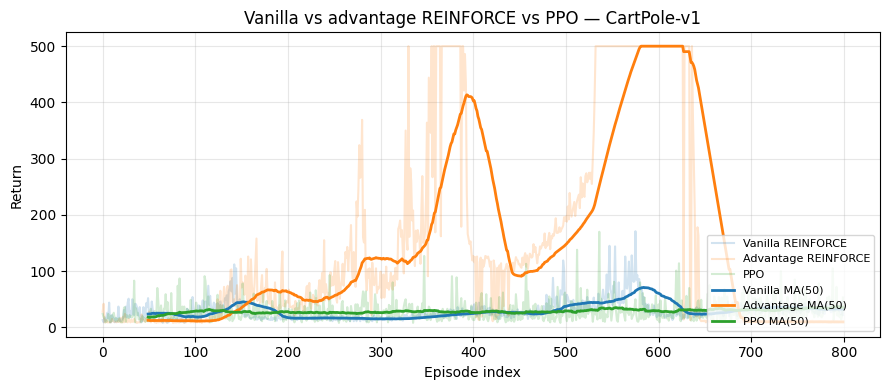

In [7]:
smooth = np.ones(SMOOTH) / SMOOTH
van = np.asarray(returns_van, dtype=np.float64)
adv = np.asarray(returns_adv, dtype=np.float64)
ppo = np.asarray(returns_ppo, dtype=np.float64)
ma_x = np.arange(SMOOTH - 1, NUM_EPISODES)

plt.figure(figsize=(9, 4))
plt.plot(van, alpha=0.2, color="C0", label="Vanilla REINFORCE")
plt.plot(adv, alpha=0.2, color="C1", label="Advantage REINFORCE")
plt.plot(ppo, alpha=0.2, color="C2", label="PPO")
plt.plot(ma_x, np.convolve(van, smooth, mode="valid"), color="C0", lw=2, label=f"Vanilla MA({SMOOTH})")
plt.plot(ma_x, np.convolve(adv, smooth, mode="valid"), color="C1", lw=2, label=f"Advantage MA({SMOOTH})")
plt.plot(ma_x, np.convolve(ppo, smooth, mode="valid"), color="C2", lw=2, label=f"PPO MA({SMOOTH})")
plt.xlabel("Episode index")
plt.ylabel("Return")
plt.title("Vanilla vs advantage REINFORCE vs PPO — CartPole-v1")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Greedy policy videos

Deterministic \(\arg\max_a \pi(a|s)\) for each trained policy.


In [8]:
def record_policy_video(policy: Policy, env_id: str, max_steps: int = 500, seed: int = 123) -> list[np.ndarray]:
    env = gym.make(env_id, render_mode="rgb_array")
    frames: list[np.ndarray] = []
    obs, _ = env.reset(seed=seed)
    done = False
    steps = 0
    policy.eval()
    with torch.no_grad():
        while not done and steps < max_steps:
            frames.append(env.render())
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            logits = policy(obs_t)
            action = int(torch.argmax(logits, dim=1).item())
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1
    env.close()
    policy.train()
    return frames


def animate_frames(frames: list[np.ndarray], interval_ms: int = 40) -> HTML:
    fig = plt.figure(figsize=(8, 5))
    ax = plt.axes([0, 0, 1, 1], frameon=False)
    ax.axis("off")
    im = ax.imshow(frames[0])

    def update(i: int):
        im.set_data(frames[i])
        return (im,)

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=interval_ms, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())


print("=== Vanilla REINFORCE ===")
display(animate_frames(record_policy_video(policy_van, ENV_ID)))

print("=== Advantage REINFORCE ===")
display(animate_frames(record_policy_video(policy_adv, ENV_ID)))

print("=== PPO ===")
display(animate_frames(record_policy_video(policy_ppo, ENV_ID)))


=== Vanilla REINFORCE ===


=== Advantage REINFORCE ===


=== PPO ===


**Note:** PPO uses **different optimization mechanics** (batched rollouts, clipping, multiple epochs) and typically smaller learning rates than REINFORCE; curves are meant for qualitative comparison, not a controlled benchmark sweep.
